# PAAS Background Variability and Relative Uncertainty Analysis

This notebook performs a full background characterization of the 
PAAS-4L instrument.

The workflow includes:

- Import of raw CSV files
- Background signal extraction
- Time averaging
- Filtering of station maintenance periods
- Statistical analysis (mean, std, RMSE, percentiles)

**Figures**:

- Temperature and RH analysis
- Laser power stability
- Background distribution analysis
- Relative uncertainty as function of absorption coefficient

All calculations are performed in physical absorption units (Mm⁻¹).

In [2]:
# 1 - Imports & Settings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm
from helper_functions import wavelength2color, plot_bg, plot_relative_uncertainty

plt.rcParams.update({
    "font.size": 12,
    "axes.linewidth": 1.5
})

# Instrument and campaign settings
instrument_SN = "PAAS-4L-02-005"
campaign = "Hyytiälä"
wavelengths = [405, 473, 515, 660]

time_av = 6  # hours

# Folder path to raw data
datafolder = Path(f"/Users/emma/Documents/Field campaigns/{campaign}/Data/PAAS/raw data weekly/")

# Folder path where to save figures (if empty (''), no figures will be saved)
savefolder = Path(f"/Users/emma/Documents/Field campaigns/{campaign}/Data/PAAS/plots/")

#analysis_period = pd.to_datetime(["2021-12-22 00:00:00", "2023-06-11 23:59:59"]) # Pallas
analysis_period = pd.to_datetime(["2024-03-21 00:00:00", "2025-07-30 23:59:59"]) # Hyytiälä

## Saturation Vapor Pressure (Goff–Gratch, 1946)

Used to estimate relative humidity inside the PA cell.

In [4]:
def svp(T):
    """
    Saturation vapor pressure (Pa)
    Goff & Gratch (1946)
    T in Kelvin
    """
    Ts = 373.15
    Ps = 101324.6
    
    log10SVP = (
        -7.90298*(Ts/T - 1)
        + 5.02808*np.log10(Ts/T)
        - 1.3816e-7*(10**(11.344*(1 - T/Ts)) - 1)
        + 8.1328e-3*(10**(3.49149*(1 - Ts/T)) - 1)
        + np.log10(Ps)
    )
    return 10**log10SVP

## Read Raw Data and Determine the Cell Constant

All CSV files are merged into one pandas DataFrame.

The photoacoustic cell constant is stored in the raw data column: `Calibration_CellConstant`

This value corresponds to the calibration constant (in V·m·W⁻¹) defined in the `MachineCfg.ini` file.

### Important: Gain Dependence of the Cell Constant

The calibration cell constant is only valid for the specific lock-in amplifier gain that was used during calibration.  
However, routine measurements may be performed at a different lock-in gain.
Since the cell constant depends on the lock-in sensitivity, a gain correction factor must be applied.

---

## Lock-In Gain Correction Factor

The intrinsic cell constant $ c_\mathrm{cell} $ is an instrument property and can be treated as a device parameter.  

If calibration and measurements are performed at different total gains, the difference must be corrected using:

$$
f_G = \frac{G_\mathrm{cal}}{G_\mathrm{meas}}
$$

where:

- $ G_\mathrm{cal} $ = total lock-in gain during calibration  
- $ G_\mathrm{meas} $ = total lock-in gain during measurement  

The effective cell constant used for data evaluation becomes:

$$
c_\mathrm{eff} = \frac{c_\mathrm{cell} }{f_G}
$$


### Where to Find These Parameters in the Raw Data

| Parameter | Column Name | Description |
|-----------|------------|------------|
| Calibration Cell Constant | `Calibration_CellConstant` | Cell constant in V·m·W⁻¹ defined in `MachineCfg.ini` |
| Calibration Gain | `Calibration_Gain` | Total lock-in amplifier gain used during calibration |
| Measurement Gain | `Lockin_Gain` | Total lock-in amplifier gain used during measurement |

In [6]:
files = list(datafolder.glob("*.csv"))

paas_list = []

for file in files:
    df = pd.read_csv(file)
    paas_list.append(df)

paas = pd.concat(paas_list, ignore_index=True)

# Time handling
paas["TimeStamp"] = pd.to_datetime(paas["TimeStamp"])
paas = paas.sort_values("TimeStamp")

c_unique = paas["Calbration_CellConstant"].dropna().unique()
Gcal_unique = paas["Calibration_Gain"].dropna().unique()
Gm_unique = paas["Lockin_Gain"].dropna().unique()

# --- Case 1: Fully constant instrument parameters ---
if len(c_unique) == 1 and len(Gcal_unique) == 1 and len(Gm_unique) == 1:

    c_cell = c_unique[0]
    G_cal = Gcal_unique[0]
    G_m = Gm_unique[0]

    print("Calibration parameters are constant.")
    print(f"  c_cell = {c_cell}")
    print(f"  G_cal = {G_cal}")
    print(f"  G_m = {G_m}")

    # Gain correction factor 
    f = G_cal / G_m
    c_cell_corr = c_cell / f
    print(f"  corrected c_cell = {c_cell_corr}")

# --- Case 2: Calibration parameters vary ---
else:

    print("WARNING: Calibration parameters vary in dataset.")
    print(f"  Unique cell constants: {c_unique}")
    print(f"  Unique calibration gains: {Gcal_unique}")
    print("Applying row-wise gain correction.")

    paas["f_G"] = (
        paas["Calibration_Gain"] /
        paas["Lockin_Gain"]
    )

    paas["CellConstant_eff"] = (
        paas["Calibration_CellConstant"] *
        paas["f_G"]
    )

Calibration parameters are constant.
  c_cell = 5700
  G_cal = 30
  G_m = 300
  corrected c_cell = 57000.0


## Extract Background Measurements

Background is defined as:

Relay1 == -1  
Laser index 0–3 corresponding to four wavelengths.

The background measurement is converted as absorption coefficient equivalent following:

$$
b_{\mathrm{abs}} =
\frac{R}
{P \cdot c_{\mathrm{cell, corr}}}
$$

where:

- $b_{\mathrm{abs}}$ – Absorption coefficient (measured quantity of the PAAS)  
- $R$ [V] – Measured microphone signal (lock-in amplifier output voltage)  
- $P$ [W] – Laser power  
- $c_{\mathrm{cell, corr}}$ [V·m·W$^{-1}$] – Corrected (effective) cell constant 

In [8]:
bg = paas[paas["Relay1"] == -1].copy()

def extract_bg(laser_index):
    d = bg[bg["Laser"] == laser_index].copy()
    d["b_abs"] = d["R"] / d["Power"] / c_cell_corr
    d["diff"] = d["b_abs"].diff()
    return d

bg_405 = extract_bg(0)
bg_473 = extract_bg(1)
bg_515 = extract_bg(2)
bg_660 = extract_bg(3)

## Time Averaging

In [10]:
def resample_bg(df):
    df = df.set_index("TimeStamp")
    return df.resample(f"{time_av}h").mean(numeric_only=True)

bg_405 = resample_bg(bg_405)
bg_473 = resample_bg(bg_473)
bg_515 = resample_bg(bg_515)
bg_660 = resample_bg(bg_660)

## Remove Periods
In Pallas station maintanance was performed on 12.4.2022 

In [12]:
work_period = pd.to_datetime(["2022-04-12 00:00:00",
                               "2022-04-12 23:59:59"])

for df in [bg_405, bg_473, bg_515, bg_660]:
    df.loc[work_period[0]:work_period[1], :] = np.nan

## Background Statistics

In [14]:
def stats(df):
    mean = df["diff"].mean()
    std = df["diff"].std()
    rmse = np.sqrt(np.nanmean(df["diff"]**2))
    p25, p75 = np.nanpercentile(df["diff"], [25,75])
    return mean, std, rmse, p25, p75

stats_405 = stats(bg_405)
stats_473 = stats(bg_473)
stats_515 = stats(bg_515)
stats_660 = stats(bg_660)

rmse_405 = stats_405[2]
rmse_473 = stats_473[2]
rmse_515 = stats_515[2]
rmse_660 = stats_660[2]

## Temperature and Relative Humidity
Calculates relative humidity inside the cell assuming a fixed cell temperature of 31$^{\circ}$C and using the temperature and RH measurements downstream the PAAS cell.

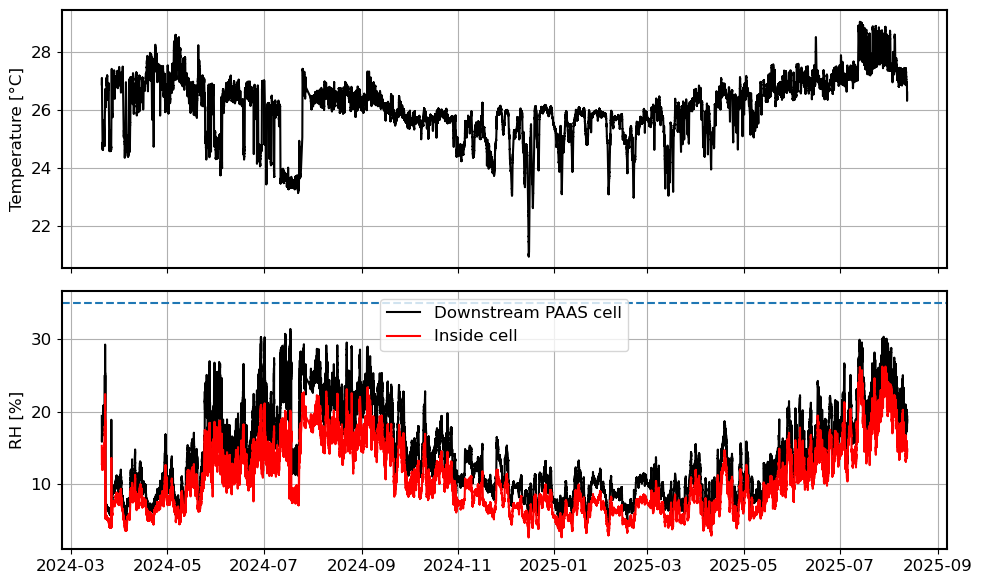

In [16]:
T_cell_fixed = 31.0

T = paas["Temperature"]
RH = paas["Humidity"]

pvp = RH/100 * svp(T + 273.15)
rh_cell_fixed = pvp / svp(T_cell_fixed + 273.15) * 100

fig, axs = plt.subplots(2,1, figsize=(10,6), sharex=True)

axs[0].plot(paas["TimeStamp"], T, color='k', label="Downstream PAAS cell")
axs[0].set_ylabel("Temperature [°C]")
axs[0].grid(True)

axs[1].plot(paas["TimeStamp"], RH, color='k', label="Downstream PAAS cell")
axs[1].plot(paas["TimeStamp"], rh_cell_fixed, color='r', label="Inside cell")
axs[1].axhline(35, linestyle="--")
axs[1].set_ylabel("RH [%]")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

## Laser power variation

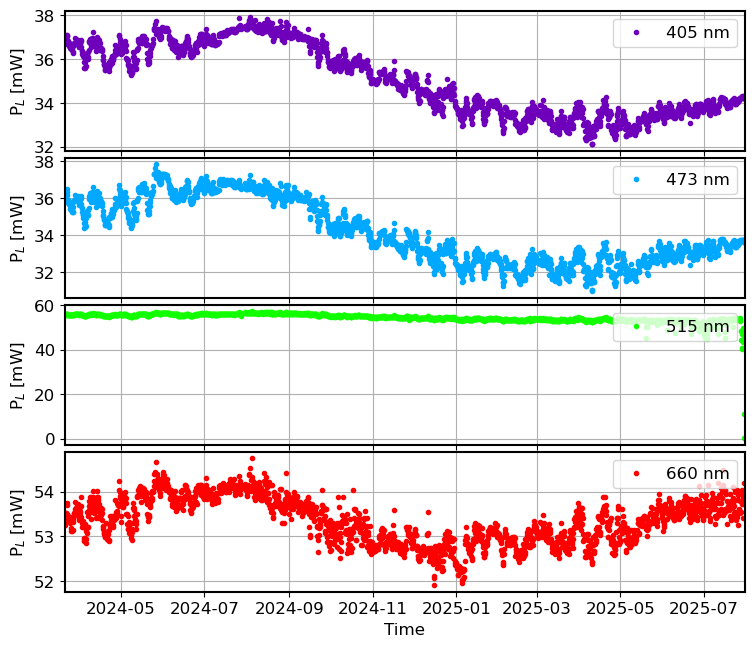

In [18]:
# List of DataFrames, wavelengths, and vertical positions
dfs = [bg_405, bg_473, bg_515, bg_660]
positions = [0.77, 0.56, 0.35, 0.14]

fig = plt.figure(figsize=(8, 7))

for df, wl, pos in zip(dfs, wavelengths, positions):
    color = wavelength2color(wl, gammaVal=1, maxIntensity=1, colorSpace='rgb')
    ax = fig.add_axes([0.075, pos, 0.85, 0.2])
    ax.plot(df.index, df['Power']*1000, '.', color=color)  # Power in mW
    ax.set_xlim(analysis_period)  # [start_datetime, end_datetime]
    # ax.set_ylim(...)  # optionally set y-limits
    ax.set_ylabel('P$_L$ [mW]')
    ax.grid(True)
    ax.tick_params(axis='x', labelbottom=False if pos>0.14 else True)  # only bottom x-axis shows labels
    ax.legend([f'{wl} nm'], loc='upper right')

plt.xlabel('Time')
plt.show()

## Histograms of background variation
Difference between the two filtered-air (background) measurements of all filter sample filter cycles that were conducted over the campaign period. Typically, each data point reflects the difference between two consecutive 1 min averaged filtered-air measurements that are 30 min apart

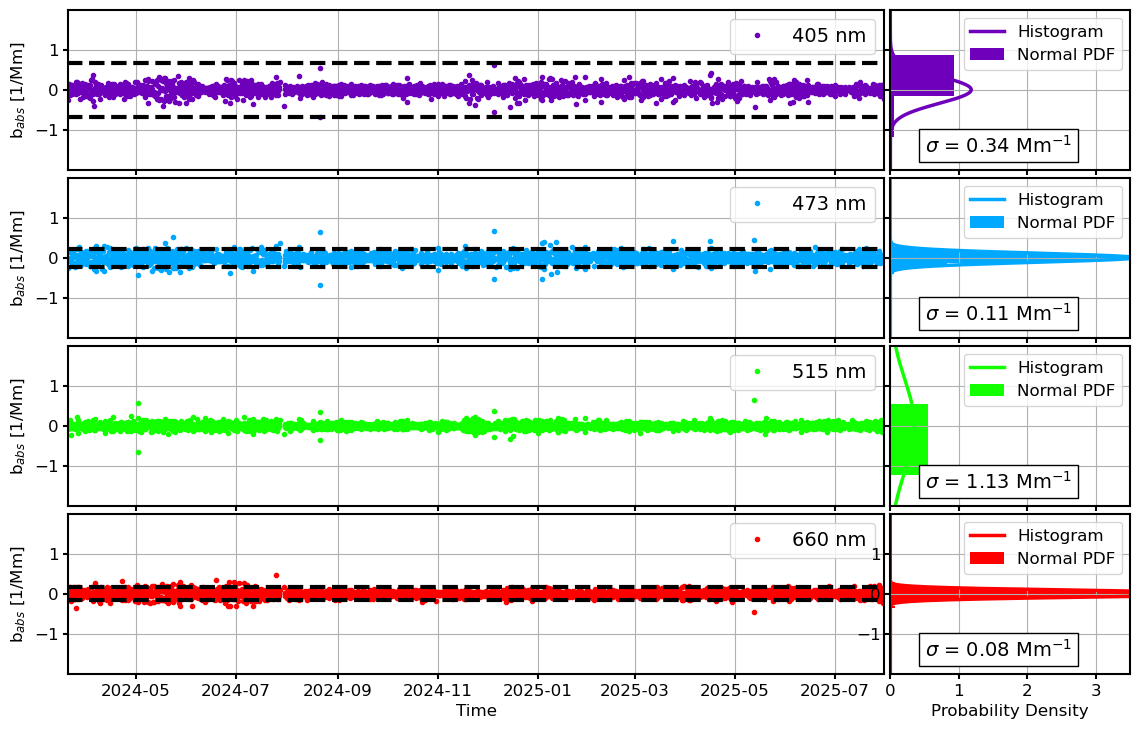

In [20]:
plot_bg(
    bg_405, bg_473, bg_515, bg_660,
    rmse_405, rmse_473, rmse_515, rmse_660,
    wavelengths, analysis_period
)

## Relative Uncertainty vs Absorption
Relative uncertainty in percent is defined as:
$$
\varepsilon_{\mathrm{rel}}(\%) =
100 \frac{\sigma}{\beta_{\mathrm{abs}}}
$$

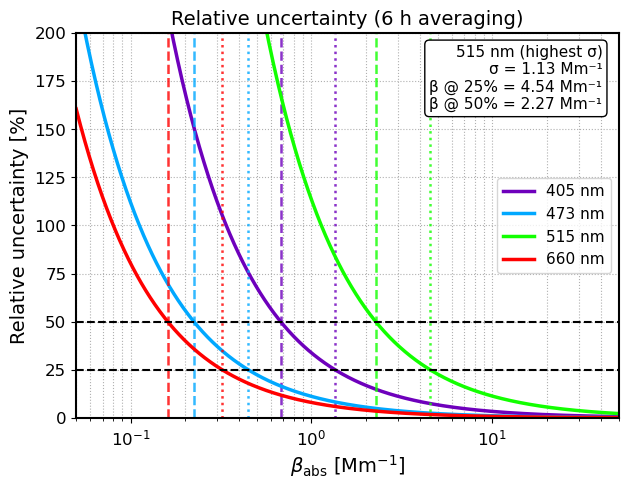

In [22]:
rmses = [rmse_405, rmse_473, rmse_515, rmse_660]
plot_relative_uncertainty(
    rmses=rmses,
    wavelengths=wavelengths,
    time_av=time_av,
    savefolder=savefolder
)